# Positional Information Ablation

This experiment reuses the Tiny Transformer classifier and changes one component: learned positional embeddings. The aim is to turn the earlier implementation into a small controlled comparison.

## What I wanted to understand

The complete Tiny Transformer can learn whether `A` appears before `B`. Does it still learn that rule when token positions are not supplied?

The sequences have the same token counts in both classes, so token identity alone should not determine the label.

In [1]:
%matplotlib inline

from itertools import combinations, product
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Markdown, SVG, display
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from model import TinyTransformerClassifier

torch.use_deterministic_algorithms(True)
plt.rcParams['figure.dpi'] = 120
figures_dir = Path('figures')
figures_dir.mkdir(exist_ok=True)

print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.13.0


## Dataset

Each sequence begins with `[CLS]`, then contains exactly one `A`, one `B`, and four filler tokens. Label `1` means `A` is before `B`; label `0` means `B` is before `A`. Every positive example has a matched negative partner with the same fillers and positions, but with `A` and `B` swapped.

The dataset is generated once with seed `7`: 400 matched pairs form the 800-example training split and 100 matched pairs form the 200-example validation split. Both splits are exactly balanced, disjoint, and shared by every run.

In [2]:
DATASET_SEED = 7
vocabulary = ['[CLS]', 'A', 'B', 'X', 'Y', 'Z']
token_to_id = {token: index for index, token in enumerate(vocabulary)}
id_to_token = {index: token for token, index in token_to_id.items()}
content_length = 6
seq_len = content_length + 1

def make_matched_dataset(num_train_pairs, num_validation_pairs, seed):
    generator = torch.Generator().manual_seed(seed)
    filler_ids = range(token_to_id['X'], len(vocabulary))
    pairs = []

    for first_position, second_position in combinations(range(content_length), 2):
        filler_positions = [position for position in range(content_length) if position not in (first_position, second_position)]
        for fillers in product(filler_ids, repeat=len(filler_positions)):
            positive_content = [None] * content_length
            negative_content = [None] * content_length
            positive_content[first_position], positive_content[second_position] = token_to_id['A'], token_to_id['B']
            negative_content[first_position], negative_content[second_position] = token_to_id['B'], token_to_id['A']
            for position, filler in zip(filler_positions, fillers):
                positive_content[position] = filler
                negative_content[position] = filler
            pairs.append(([token_to_id['[CLS]']] + positive_content, [token_to_id['[CLS]']] + negative_content))

    total_pairs = num_train_pairs + num_validation_pairs
    selected_indices = torch.randperm(len(pairs), generator=generator)[:total_pairs].tolist()
    selected_pairs = [pairs[index] for index in selected_indices]
    train_pairs = selected_pairs[:num_train_pairs]
    validation_pairs = selected_pairs[num_train_pairs:]

    def flatten_and_shuffle(pair_list):
        token_ids = torch.tensor([sequence for pair in pair_list for sequence in pair])
        labels = torch.tensor([label for _ in pair_list for label in [1, 0]])
        shuffle_order = torch.randperm(len(labels), generator=generator)
        return token_ids[shuffle_order], labels[shuffle_order]

    train_token_ids, train_labels = flatten_and_shuffle(train_pairs)
    validation_token_ids, validation_labels = flatten_and_shuffle(validation_pairs)
    example_pair_token_ids = torch.tensor(validation_pairs[0])
    example_pair_labels = torch.tensor([1, 0])
    return train_token_ids, train_labels, validation_token_ids, validation_labels, example_pair_token_ids, example_pair_labels

train_token_ids, train_labels, validation_token_ids, validation_labels, example_pair_token_ids, example_pair_labels = make_matched_dataset(
    num_train_pairs=400, num_validation_pairs=100, seed=DATASET_SEED
)
all_token_ids = torch.cat([train_token_ids, validation_token_ids])

assert len(set(map(tuple, all_token_ids.tolist()))) == 1000
assert torch.bincount(train_labels).tolist() == [400, 400]
assert torch.bincount(validation_labels).tolist() == [100, 100]
assert set(map(tuple, train_token_ids.tolist())).isdisjoint(map(tuple, validation_token_ids.tolist()))
assert example_pair_labels.tolist() == [1, 0]
print('Unique sequences: 1000')
print('Train class counts:', torch.bincount(train_labels).tolist())
print('Validation class counts:', torch.bincount(validation_labels).tolist())
print('Train / validation split: 800 / 200')
print('Train and validation sequences are disjoint: True')

Unique sequences: 1000
Train class counts: [400, 400]
Validation class counts: [100, 100]
Train / validation split: 800 / 200
Train and validation sequences are disjoint: True


## With vs without positional embeddings

Both models create the same layers in the same order. One adds learned position vectors to token embeddings; the other keeps that table unused and sends token embeddings directly to the same encoder block.

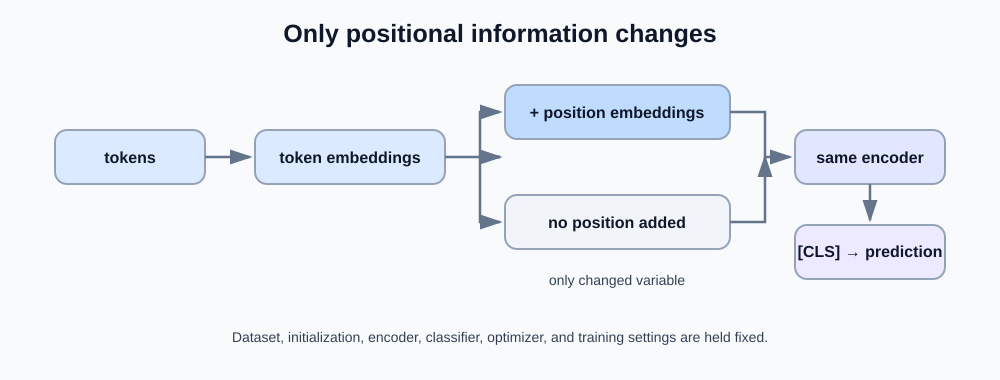

In [3]:
display(SVG(filename=str(figures_dir / 'architecture-flow.svg')))

In [4]:
d_model = 32
num_heads = 4
d_ff = 64
num_classes = 2

torch.manual_seed(101)
with_positions = TinyTransformerClassifier(len(vocabulary), seq_len, d_model, num_heads, d_ff, num_classes, use_positions=True)
torch.manual_seed(101)
without_positions = TinyTransformerClassifier(len(vocabulary), seq_len, d_model, num_heads, d_ff, num_classes, use_positions=False)

assert with_positions(train_token_ids[:4]).shape == without_positions(train_token_ids[:4]).shape == (4, 2)
for (with_name, with_parameter), (without_name, without_parameter) in zip(with_positions.named_parameters(), without_positions.named_parameters()):
    assert with_name == without_name
    assert torch.equal(with_parameter, without_parameter)
print('Both conditions produce logits shaped [batch, 2].')
print('Same-seed models have identical shared initial weights.')
print('The no-position model keeps its position table but does not add it to token embeddings.')

Both conditions produce logits shaped [batch, 2].
Same-seed models have identical shared initial weights.
The no-position model keeps its position table but does not add it to token embeddings.


## Training setup

Both conditions use one encoder block, `d_model=32`, four attention heads, a `32 → 64 → 32` FFN, `[CLS]` classification, AdamW with learning rate `0.003` and weight decay `0.0001`, batch size `64`, and 30 epochs.

For each seed, both conditions begin with identical shared weights and use the same batch order. The dataset split never changes.

In [5]:
batch_size = 64
epochs = 30
learning_rate = 0.003
weight_decay = 0.0001
seeds = [7, 13, 23, 37, 53]

histories = {}
example_predictions = {}

def evaluate(model, loader, loss_function):
    model.eval()
    total_loss = total_correct = total_examples = 0
    with torch.no_grad():
        for token_ids, labels in loader:
            logits = model(token_ids)
            total_loss += loss_function(logits, labels).item() * len(labels)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += len(labels)
    return total_loss / total_examples, total_correct / total_examples

def train_and_evaluate(seed, use_positions):
    torch.manual_seed(seed)
    model = TinyTransformerClassifier(
        vocab_size=len(vocabulary), seq_len=seq_len, d_model=d_model, num_heads=num_heads,
        d_ff=d_ff, num_classes=num_classes, use_positions=use_positions,
    )
    train_loader = DataLoader(
        TensorDataset(train_token_ids, train_labels), batch_size=batch_size, shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    validation_loader = DataLoader(TensorDataset(validation_token_ids, validation_labels), batch_size=batch_size)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    history = {'train_loss': [], 'validation_loss': [], 'train_accuracy': [], 'validation_accuracy': []}

    for _ in range(epochs):
        model.train()
        for token_ids, labels in train_loader:
            loss = loss_function(model(token_ids), labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        train_loss, train_accuracy = evaluate(model, train_loader, loss_function)
        validation_loss, validation_accuracy = evaluate(model, validation_loader, loss_function)
        history['train_loss'].append(train_loss)
        history['validation_loss'].append(validation_loss)
        history['train_accuracy'].append(train_accuracy)
        history['validation_accuracy'].append(validation_accuracy)

    condition = 'With positional information' if use_positions else 'Without positional information'
    histories[(seed, condition)] = history
    with torch.no_grad():
        probabilities = torch.softmax(model(example_pair_token_ids), dim=1)
    example_predictions[condition] = (probabilities.argmax(dim=1), probabilities)
    return {
        'seed': seed,
        'condition': condition,
        'train_loss': history['train_loss'][-1],
        'validation_loss': history['validation_loss'][-1],
        'train_accuracy': history['train_accuracy'][-1],
        'validation_accuracy': history['validation_accuracy'][-1],
    }

## Run five fixed seeds

Each pair of runs starts from the same seed. The nested loop makes the comparison explicit: only `use_positions` changes within a seed.

In [6]:
results = []

for seed in seeds:
    for use_positions in [True, False]:
        metrics = train_and_evaluate(
            seed=seed,
            use_positions=use_positions,
        )
        results.append(metrics)

print(f'Completed {len(results)} runs.')

Completed 10 runs.


## Collecting results

The DataFrame keeps the final metrics for every run in one place before aggregating them.

In [7]:
results_df = pd.DataFrame(results)
results_df

,seed,condition,train_loss,validation_loss,train_accuracy,validation_accuracy
0,7,With positional information,0.000171,0.000172,1.0,1.0
1,7,Without positional information,0.693150,0.693150,0.5,0.5
2,13,With positional information,0.000117,0.000117,1.0,1.0
3,13,Without positional information,0.693833,0.693840,0.5,0.5
4,23,With positional information,0.000222,0.000222,1.0,1.0
5,23,Without positional information,0.693214,0.693213,0.5,0.5
6,37,With positional information,0.000147,0.000147,1.0,1.0
7,37,Without positional information,0.693567,0.693571,0.5,0.5
8,53,With positional information,0.000225,0.000225,1.0,1.0
9,53,Without positional information,0.694396,0.694408,0.5,0.5


In [8]:
summary_df = (
    results_df.groupby('condition', sort=False)['validation_accuracy']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'mean validation accuracy', 'std': 'std'})
    .reset_index()
)
summary_df

,condition,mean validation accuracy,std
0,With positional information,1.0,0.0
1,Without positional information,0.5,0.0


## Comparing runs

The first plot shows the final validation result for each seed. The second shows validation learning behavior as a mean curve with a ±1 standard-deviation band.

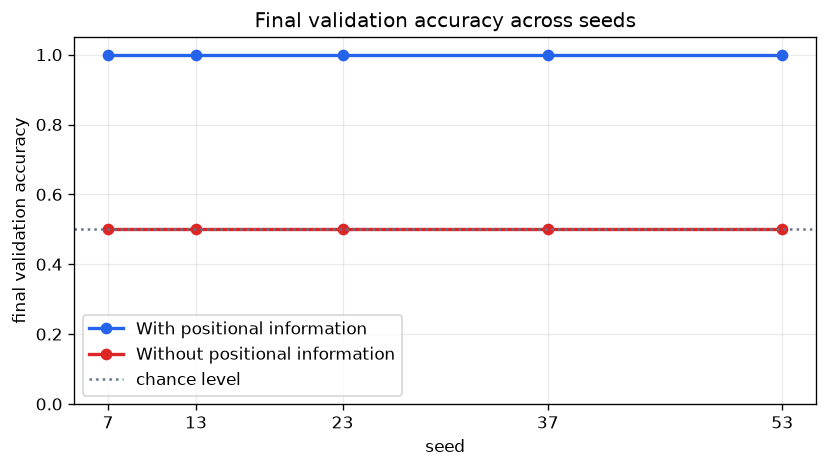

In [9]:
colors = {'With positional information': '#2563eb', 'Without positional information': '#dc2626'}

fig, ax = plt.subplots(figsize=(7, 4))
for condition, group in results_df.groupby('condition', sort=False):
    ax.plot(group['seed'], group['validation_accuracy'], marker='o', linewidth=2, color=colors[condition], label=condition)

ax.axhline(0.5, color='#64748b', linestyle=':', label='chance level')
ax.set_xlabel('seed')
ax.set_xticks(seeds)
ax.set_ylabel('final validation accuracy')
ax.set_ylim(0.0, 1.05)
ax.set_title('Final validation accuracy across seeds')
ax.grid(alpha=0.25)
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(figures_dir / 'validation-accuracy-by-seed.png', bbox_inches='tight')
plt.show()

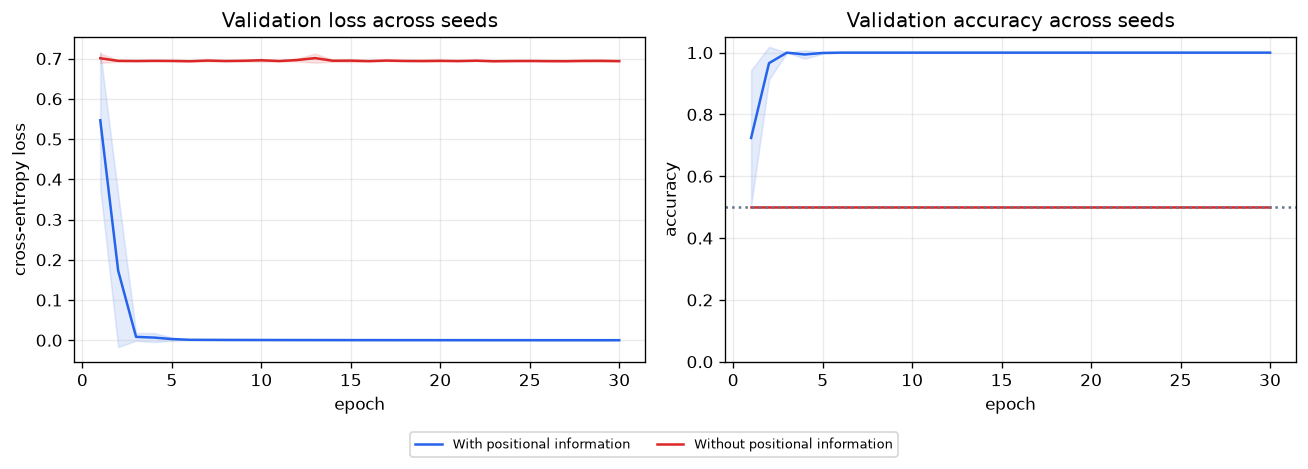

In [10]:
epochs_axis = range(1, epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for condition in colors:
    condition_histories = [histories[(seed, condition)] for seed in seeds]
    for metric, axis, title, ylabel in [
        ('loss', axes[0], 'Validation loss across seeds', 'cross-entropy loss'),
        ('accuracy', axes[1], 'Validation accuracy across seeds', 'accuracy'),
    ]:
        validation_values = torch.tensor([history[f'validation_{metric}'] for history in condition_histories])
        validation_mean, validation_std = validation_values.mean(dim=0), validation_values.std(dim=0)
        axis.plot(epochs_axis, validation_mean, color=colors[condition], label=condition)
        axis.fill_between(epochs_axis, validation_mean - validation_std, validation_mean + validation_std, color=colors[condition], alpha=0.12)
        axis.set_title(title)
        axis.set_xlabel('epoch')
        axis.set_ylabel(ylabel)
        axis.grid(alpha=0.25)

axes[1].set_ylim(0.0, 1.05)
axes[1].axhline(0.5, color='#64748b', linestyle=':')
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=8, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(figures_dir / 'training-curves.png', bbox_inches='tight')
plt.show()

## Inspecting examples

These are a matched held-out pair: the filler tokens and positions stay the same, while `A` and `B` swap places. The displayed predictions come from the final seed (`53`) for each condition.

In [11]:
table_lines = [
    '| matched tokens | true rule | with positions | without positions |',
    '| --- | --- | --- | --- |',
]
with_predictions, with_probabilities = example_predictions['With positional information']
without_predictions, without_probabilities = example_predictions['Without positional information']

for row, token_ids in enumerate(example_pair_token_ids):
    tokens = ' '.join(id_to_token[token_id] for token_id in token_ids.tolist())
    with_label = with_predictions[row].item()
    without_label = without_predictions[row].item()
    with_confidence = with_probabilities[row, with_label].item()
    without_confidence = without_probabilities[row, without_label].item()
    true_rule = 'A before B' if example_pair_labels[row].item() == 1 else 'B before A'
    table_lines.append(
        f'| `{tokens}` | {true_rule} | {with_label} ({with_confidence:.3f}) | {without_label} ({without_confidence:.3f}) |'
    )

display(Markdown('\n'.join(table_lines)))

| matched tokens | true rule | with positions | without positions |
| --- | --- | --- | --- |
| `[CLS] Y Y X Z A B` | A before B | 1 (1.000) | 0 (0.525) |
| `[CLS] Y Y X Z B A` | B before A | 0 (1.000) | 0 (0.525) |

## What I observed

Use the table and plots above as the record of this run. The comparison tests a narrow expectation: the positional condition can represent the order rule, while the no-position condition cannot use token order through this architecture.

## Limitations

This is a deliberately small synthetic task, not a language-understanding benchmark. It compares learned absolute positions with no positional information; it does not compare sinusoidal encodings, relative positions, RoPE, or long-context behavior.